# FASE 3a: GENERADOR DE TENSORES HÍBRIDOS (MediaPipe)

**Autor:** Andoni Cabrera Fernández

**Descripción Técnica:** En este cuaderno se realiza el preprocesamiento del conjunto de datos original. Se utiliza la API de MediaPipe (`FaceLandmarker`) para detectar la malla facial y aislar las regiones de interés (ROI) correspondientes a los ojos y la boca.

Ambas regiones se concatenan verticalmente para generar un tensor híbrido unificado de 224x224x3 píxeles. Este proceso elimina el fondo, el cabello y el contorno facial, actuando como un filtro que reduce drásticamente la información de identidad del sujeto (sesgo de identidad) detectado en las Fases 1 y 2.

## 1. INSTALACIÓN E INFRAESTRUCTURA
Instalación de la librería MediaPipe, montaje del sistema de archivos de Google Drive y descompresión del conjunto de datos original en el almacenamiento local del entorno de ejecución.

In [ ]:
# Instalación de MediaPipe y descarga del modelo de landmarks
!pip install -q mediapipe
!wget -O face_landmarker.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

from google.colab import drive
import os

# Montar Drive
drive.mount('/content/drive')

# Rutas de trabajo
ruta_zip_original = '/content/drive/MyDrive/TFG_Fatiga_Colab/Caras_Recortadas_Procesadas.zip'
ruta_local_extrac = '/content/dataset_caras'
ruta_destino_local = '/content/dataset_hibrido'

# Descomprimir dataset holístico original en el entorno local de Colab
if not os.path.exists(ruta_local_extrac):
    print("Descomprimiendo el dataset original holístico...")
    !unzip -q "{ruta_zip_original}" -d "{ruta_local_extrac}"
    print("¡Descompresión completada!")
else:
    print("El dataset original ya está en la memoria temporal.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descomprimiendo el dataset original holístico...
¡Descompresión completada!


## 2. EXTRACCIÓN DE ROIs Y CREACIÓN DEL TENSOR HÍBRIDO
Configuración del modelo `FaceLandmarker` y definición de las funciones de recorte. A partir de los puntos de referencia faciales, se extraen las coordenadas de los ojos y la boca, se redimensionan y se concatenan verticalmente. Finalmente, se procesa secuencialmente todo el conjunto de datos, integrando bloques para descartar fotogramas inválidos o sin rostro detectado.

In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
from tqdm import tqdm

# 1. Configuración del motor FaceLandmarker
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(base_options=base_options, num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

# 2. Función base para transformar la imagen en un tensor híbrido
def crear_tensor_hibrido(ruta_imagen):
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None: return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_bgr.shape

    # Conversión al formato estricto de MediaPipe
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    resultados = detector.detect(mp_image)

    # Filtrar si no se detecta la malla facial
    if not resultados.face_landmarks: return None

    landmarks = resultados.face_landmarks[0]

    # --- EXTRACCIÓN REGIÓN OCULAR ---
    indices_ojos = [33, 133, 362, 263, 70, 300]
    x_ojos = [int(landmarks[i].x * w) for i in indices_ojos]
    y_ojos = [int(landmarks[i].y * h) for i in indices_ojos]

    # Aplicación de márgenes de seguridad para no cortar los párpados
    x_min_ojo, x_max_ojo = max(0, min(x_ojos) - 20), min(w, max(x_ojos) + 20)
    y_min_ojo, y_max_ojo = max(0, min(y_ojos) - 30), min(h, max(y_ojos) + 30)
    recorte_ojos = img_bgr[y_min_ojo:y_max_ojo, x_min_ojo:x_max_ojo]

    # --- EXTRACCIÓN REGIÓN BUCAL ---
    indices_boca = [78, 308, 13, 14, 0, 17]
    x_boca = [int(landmarks[i].x * w) for i in indices_boca]
    y_boca = [int(landmarks[i].y * h) for i in indices_boca]

    # Aplicación de márgenes de seguridad
    x_min_boca, x_max_boca = max(0, min(x_boca) - 20), min(w, max(x_boca) + 20)
    y_min_boca, y_max_boca = max(0, min(y_boca) - 20), min(h, max(y_boca) + 20)
    recorte_boca = img_bgr[y_min_boca:y_max_boca, x_min_boca:x_max_boca]

    # Control de errores geométricos
    if recorte_ojos.size == 0 or recorte_boca.size == 0: return None

    # --- FUSIÓN VERTICAL (CREACIÓN DEL TENSOR HÍBRIDO) ---
    # Redimensionamos a 224x112 para que al unirlos formen el 224x224 exacto de MobileNet
    ojos_resized = cv2.resize(recorte_ojos, (224, 112))
    boca_resized = cv2.resize(recorte_boca, (224, 112))
    tensor_hibrido = np.vstack((ojos_resized, boca_resized))

    return tensor_hibrido

# 3. Mapeo del Dataset Original
ruta_origen = '/content/dataset_caras/Caras_Recortadas_Procesadas'
archivos_totales = []

for raiz, carpetas, archivos in os.walk(ruta_origen):
    for archivo in archivos:
        if archivo.endswith(('.jpg', '.png')):
            archivos_totales.append(os.path.join(raiz, archivo))

print(f"Iniciando la transformación topológica de {len(archivos_totales)} imágenes...\n")

# 4. Bucle de procesamiento
img_exito = 0
img_fallo = 0

for ruta_img in tqdm(archivos_totales, desc="Creando Tensores Híbridos"):
    # Mantener la estructura original de folds y clases
    partes_ruta = ruta_img.split(os.sep)
    fold = partes_ruta[-3]
    clase = partes_ruta[-2]
    nombre_archivo = partes_ruta[-1]

    carpeta_destino = os.path.join(ruta_destino_local, fold, clase)
    os.makedirs(carpeta_destino, exist_ok=True)
    ruta_salida = os.path.join(carpeta_destino, nombre_archivo)

    # Inferencia y guardado
    img_hibrida = crear_tensor_hibrido(ruta_img)
    if img_hibrida is not None:
        cv2.imwrite(ruta_salida, img_hibrida)
        img_exito += 1
    else:
        img_fallo += 1

print(f"\nProcesamiento terminado.")
print(f"   Tensores creados con éxito: {img_exito}")
print(f"   Imágenes descartadas (sin cara o fuera de márgenes): {img_fallo}")

Iniciando la transformación topológica de 102877 imágenes...



Creando Tensores Híbridos: 100%|██████████| 102877/102877 [39:43<00:00, 43.16it/s]


Procesamiento terminado.
   Tensores creados con éxito: 102586
   Imágenes descartadas (sin cara o fuera de márgenes): 291


## 3. EMPAQUETADO Y EXPORTACIÓN
Compresión del nuevo conjunto de datos híbrido generado y exportación directa a Google Drive para su almacenamiento y uso en las posteriores fases de entrenamiento.

In [ ]:
# Comprimir y mover a Drive (Evita el cuello de botella de transferencia I/O de Drive)
ruta_salida_drive = '/content/drive/MyDrive/TFG_Fatiga_Colab/Dataset_Hibrido.zip'

print("Comprimiendo el nuevo dataset de Tensores Híbridos...")
!cd "{ruta_destino_local}" && zip -rq "{ruta_salida_drive}" .

print(f"¡Dataset final exportado con éxito a: {ruta_salida_drive}!")

Comprimiendo el nuevo dataset de Tensores Híbridos...
¡Dataset final exportado con éxito a: /content/drive/MyDrive/TFG_Fatiga_Colab/Dataset_Hibrido.zip!


## 4. VERIFICACIÓN Y MUESTREO DE TENSORES
Lectura del archivo comprimido para verificar su integridad. Se aplica un filtro ético para restringir la visualización aleatoria exclusivamente a las muestras de aquellos conductores que han dado su consentimiento explícito para la publicación de su imagen.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de Tensores Híbridos en el ZIP: 102586
Tensores Híbridos autorizados para publicación: 60012
Mostrando muestras aleatorias de 5 SUJETOS DIFERENTES...


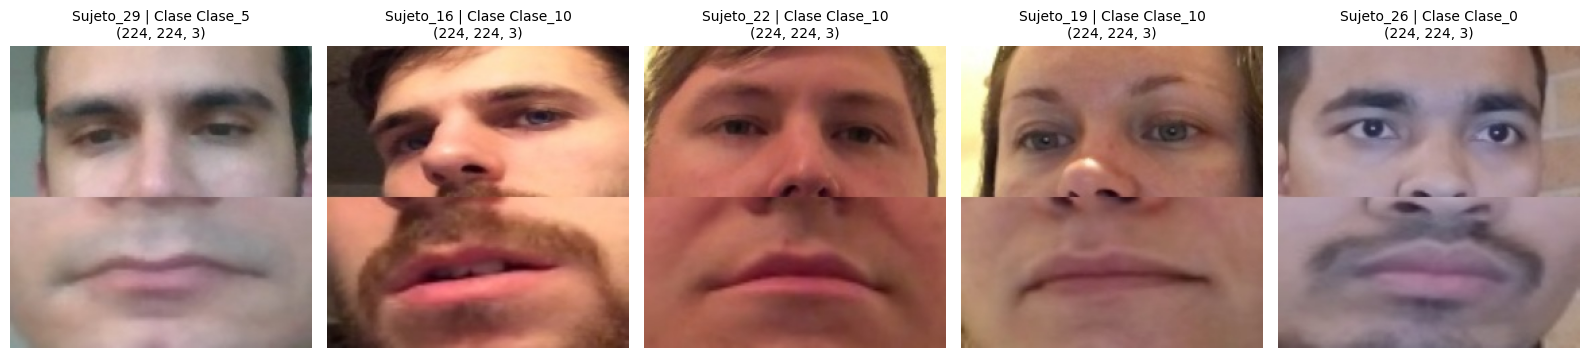

In [ ]:
from google.colab import drive
import zipfile
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Montar Google Drive y definir rutas
drive.mount('/content/drive')
ruta_zip = '/content/drive/MyDrive/TFG_Fatiga_Colab/Dataset_Hibrido.zip'

# 2. Filtro Ético: IDs con consentimiento explícito para publicación
sujetos_yes = [
    "1", "2", "4", "9", "10", "11", "13", "16", "17", "19",
    "21", "22", "23", "24", "25", "26", "28", "29", "30", "31",
    "33", "34", "42", "43", "46", "47", "48", "49", "50", "51",
    "52", "53", "55", "57", "59", "60"
]
# Formateamos para abarcar las nomenclaturas habituales (ej. Sujeto_1, Sujeto_01)
etiquetas_validas = [f"Sujeto_{s.zfill(2)}" for s in sujetos_yes] + [f"Sujeto_{s}/" for s in sujetos_yes]

if not os.path.exists(ruta_zip):
    print(f"No se encuentra el archivo en {ruta_zip}")
else:
    # Abrimos el ZIP en modo lectura
    with zipfile.ZipFile(ruta_zip, 'r') as z:
        # Buscamos todos los archivos que sean imágenes
        archivos_img = [f for f in z.namelist() if f.endswith(('.jpg', '.png'))]

        # 3. Aplicamos la criba ética filtrando los sujetos no autorizados
        archivos_permitidos = [f for f in archivos_img if any(etiqueta in f for etiqueta in etiquetas_validas)]

        print(f"Total de Tensores Híbridos en el ZIP: {len(archivos_img)}")
        print(f"Tensores Híbridos autorizados para publicación: {len(archivos_permitidos)}")

        imagenes_por_sujeto = {}
        for ruta in archivos_permitidos:
            partes = ruta.split('/')
            sujeto = partes[-3] if len(partes) >= 3 else "Desconocido"
            if sujeto not in imagenes_por_sujeto:
                imagenes_por_sujeto[sujeto] = []
            imagenes_por_sujeto[sujeto].append(ruta)

        if len(imagenes_por_sujeto) > 0:
            print("Mostrando muestras aleatorias de 5 SUJETOS DIFERENTES...")

            # 1. Seleccionar 5 sujetos únicos al azar
            sujetos_elegidos = random.sample(list(imagenes_por_sujeto.keys()), min(5, len(imagenes_por_sujeto)))

            # 2. De cada sujeto elegido, tomar una sola imagen al azar
            muestras = [random.choice(imagenes_por_sujeto[s]) for s in sujetos_elegidos]

            plt.figure(figsize=(16, 5))
            for i, ruta_img in enumerate(muestras):
                # 1. Leer los bytes de la imagen directamente del ZIP
                img_data = z.read(ruta_img)

                # 2. Convertir los bytes a un array de numpy y luego a imagen de OpenCV
                img_array = np.frombuffer(img_data, np.uint8)
                img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # 3. Extraer sujeto y clase de la ruta dentro del ZIP
                partes = ruta_img.split('/')
                clase = partes[-2] if len(partes) >= 2 else "Desconocida"
                sujeto = partes[-3] if len(partes) >= 3 else "Desconocido"

                # 4. Dibujar
                plt.subplot(1, 5, i+1)
                plt.imshow(img_rgb)
                plt.title(f"{sujeto} | Clase {clase}\n{img.shape}", fontsize=10)
                plt.axis('off')

            plt.tight_layout()
            plt.show()